# Building An Operator

Author : Henry Nachman

---

This tutorial will dive into the workings of `Operators` in TOAST. What they are, how they operate (pun intended), and the basics of how to build your own.

In [191]:
import toast
from toast.tests import helpers
from plotting_utils import *


## What is an Operator

An `Operator` is an object with methods which can be applied to `Data` objects. Each `operator` is built on the base `Operator` class. This means that `operators` _inherit_ the methods of the parent `Operator` class.

To illustrate the concept of _inheritance_ in python take the follow code example.

```python
# The parent (base) class
class Animal:
    def __init__(self, name):
        self.name = name

    def eat(self):
        print(f"{self.name} is eating.")

# The child (derived) class that "is a type of" Animal
class Dog(Animal):
    def bark(self):
        print(f"{self.name} says woof!")
```

In this case, the `Dog` class has its own methods (`bark`) but also inherits the `eat` method from the base `Animal` class. 

In TOAST, the `Operator` base class has two primary methods briefly described by their docstrings below (there are other methods but these are the most important and relevant ones):

```python
class Operator(TraitConfig):
    def exec(self, data, detectors=None, **kwargs):
        """Perform operations on a Data object.

        If a list of detectors is specified, only process these detectors.  Any extra
        kwargs are passed to the derived class internal method.

        Accelerator use:  If the derived class supports OpenMP target offload and all the required
        data objects exist on the device, then the `_exec()` method will be called
        with the "use_accel=True" option.  Any operator that returns "True" from its
        _supports_accel() method should also accept the "use_accel" keyword argument.

        Args:
            data (toast.Data):  The distributed data.
            detectors (list):  A list of detector names or indices.  If None, this
                indicates a list of all detectors.

        Returns:
            None

        """

    @function_timer_stackskip
    def apply(self, data, detectors=None, **kwargs):
        """Run exec() and finalize().

        This is a convenience wrapper that calls exec() exactly once with an optional
        detector list and then immediately calls finalize().  This is really only
        useful when working interactively to save a bit of typing.  When a `Pipeline`
        is calling other operators it will always use exec() and finalize() explicitly.

        After calling this, any future calls to exec() may produce unexpected results,
        since finalize() has already been called.

        Args:
            data (toast.Data):  The distributed data.
            detectors (list):  A list of detector names or indices.  If None, this
                indicates a list of all detectors.

        Returns:
            (value):  None or an Operator-dependent result.

        """
```

An example of an operator in TOAST is the `PointingDetectorSimple` operator.

Let's create this operator object.

In [192]:
pointing_operator = toast.ops.PointingDetectorSimple(
    boresight=defaults.boresight_azel,
    quats="quats_azel"
)

Here we have created an instance of the `PointingDetectorSimple` Operator. The two arguments we gave it are specific attributes of the `PointingDetectorSimple` class. The `PointingDetectorSimple` class has a number of attributes not specified in this object instantiation because each attribute has a default value. In the case of `PointingDetectorSimple`, the default value for the `boresight` attribute is the `boresight_radec`, we call the `Operator` with arguments to overwrite the defaults.

```python
    boresight = Unicode(
        defaults.boresight_radec, help="Observation shared key for boresight"
    )
```

Now that we have our operator, we can apply the operator to our data with the following.

In [193]:
# Let's first make make a fake observation. Before we can do that we need to define a telescope. And to do that we need to define a focal plane
from toast.instrument_sim import fake_hexagon_focalplane
from astropy import units as u

focalplane = fake_hexagon_focalplane(
    n_pix=19,
    width=10.0 * u.degree,
    sample_rate=10.0 * u.Hz,
    epsilon=0.0,
)

telescope = toast.Telescope(name="fake", focalplane=focalplane, site=toast.SpaceSite(name="L2"))


ob = toast.Observation(
    toast.Comm(),
    telescope, 
    name="test_obs", 
    n_samples=30
)

ob.detdata["signal"] = {
    x: np.ones((ob.n_local_samples), dtype=np.int16)
        for x in ob.local_detectors
}

# Start with an empty data container
data = toast.Data()
data.obs = [ob]


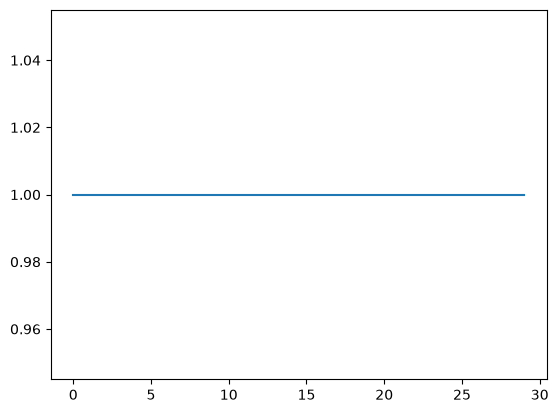

In [194]:
plt.plot(ob.detdata['signal'][0])

And like that we have applied our pointing operator to the observation data. 

What is happening in the back-end?

Well first, operator calls on the `apply` method. You might notice by taking a peek at the source code that the `PointingDetectorSimple` class does not have its own `apply` method. That means, it is _inheriting_ the `apply` method from the general `Operator` class.

The `apply` method of the parent `Operator` class runs the `exec` function. This jumps to the `exec` method in the `Operator` parent class. This in turn jumps to the `_exec` method in the specific operator.

In the case of the `PointingDetectorSimple` Operator, we see that this is where the information for how to adjust the detector pointing is encoded (and then passed to the `pointing_detector` function).

## A Simple Operator

In [195]:
from toast.ops.operator import Operator
from toast.timing import function_timer
from traitlets import Unicode, Int

In [196]:
class TestOperator(Operator):
    name = Unicode(
        "Test Operator",
        help = "The designated name of this operator"
    )

    @function_timer
    def _exec(self, data, detectors=None, use_accel=None, **kwargs):
        print(self.name)
        return

    def _finalize(self, data, **kwargs):
        return

This is a very basic example of an operator. Notice it contains two _mandatory_ methods: the `_exec` and the `_finalize` methods. Without these, toast will through an error.

In [197]:
henry_operator = TestOperator(name = "Henry Operator")

henry_operator.apply(data)

Henry Operator


Let's make another operator - this one that actually does something:

In [198]:
class ToInfinityAndBeyond(Operator):
    """
    Description: The purpose of this operator is to make a detector time stream that is slowly increasing...
    To infinity and beyond.
    """

    rate = Int(
        5,
        "The rate of increase of the data."
    )

    @function_timer
    def _exec(self, data, detectors=None, use_accel=None, **kwargs):
        # print(self.rate)
        # Make an array of the length of data
        data_shape = np.shape(data.obs[0].detdata["signal"])
        n_samp = data_shape[1]
        new_data = np.polyval([self.rate, 0], np.arange(n_samp))

        for ob in data.obs:
            if detectors is not None:
                for detector in detectors:
                    ob.detdata["signal"][detector] = new_data + ob.detdata["signal"][detector]

        return
    
    def _finalize(self, data, **kwargs):
        return

Now we apply the new operator to the data for a particular detector.

In [199]:
slow_increase = ToInfinityAndBeyond(rate=2)

slow_increase.apply(data, detectors = ["D00A-150"])

In [200]:
print(ob.detdata)

<DetDataManager 38 local detectors, 30 samples
    signal: shape=(38, 30), dtype=int16, units=''>


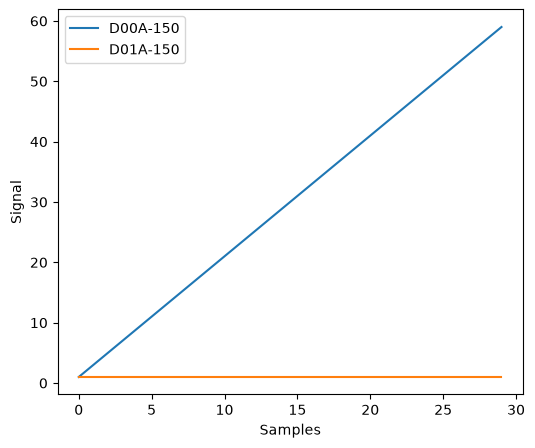

In [201]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.plot(ob.detdata['signal']["D00A-150"], label=["D00A-150"][0])
plt.plot(ob.detdata['signal']["D01A-150"], label=["D01A-150"][0])
plt.xlabel("Samples")
plt.ylabel("Signal")
plt.legend()
plt.show()

Here we can see the effect of our Operator next that was applied to the _D00A-150_ detector, compared to the signal timestream from the _D01A-150_ detector that was not altered.

Let's make another operator that does something different.

In [ ]:
class SeaSick(Operator):
    """
    Description: The purpose of this operator is to make a detector time stream that 
    imitates my cousin on a boat.
    """

    sine_freq = Int(
        1,
        "The frequency of the sine wave."
    )

    sine_amp = Int(
        2,
        "The amplitude of the sine wave."
    )

    noise_amp = Int(
        5,
        "The noise amplitude."
    )

    @function_timer
    def _exec(self, data, detectors=None, use_accel=None, **kwargs):
        # Make an array of the length of data
        data_shape = np.shape(data.obs[0].detdata["signal"])
        n_samp = data_shape[1]
        new_data = np.array(self.sine_amp*np.sin(self.sine_freq*np.arange(n_samp)), dtype=float)
        # Add a random guassian noise to the data
        noise = self.noise_amp*np.random.random(n_samp)
        new_data = new_data + noise

        for ob in data.obs:
            if detectors is not None:
                for detector in detectors:
                    ob.detdata["signal"][detector] = new_data + ob.detdata["signal"][detector]

        return
    
    def _finalize(self, data, **kwargs):
        return

Let's apply our new operator to a different detector.

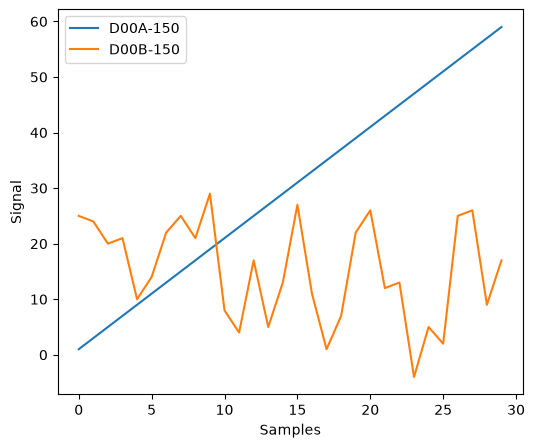

In [203]:
seasick = SeaSick(sine_freq = 1, sine_amp = 10, noise_amp = 25)

seasick.apply(data, detectors = ["D00B-150"])

plt.figure(figsize=(6,5))
plt.plot(ob.detdata['signal']['D00A-150'], label = 'D00A-150')
plt.plot(ob.detdata['signal']['D00B-150'], label = 'D00B-150')
plt.xlabel("Samples")
plt.ylabel("Signal")
plt.legend()
plt.show()

The great thing about these operators is that they can be applied linearly to a detector. Here we will apply both the `slow_increase` and `seasick` operators to a third detector.

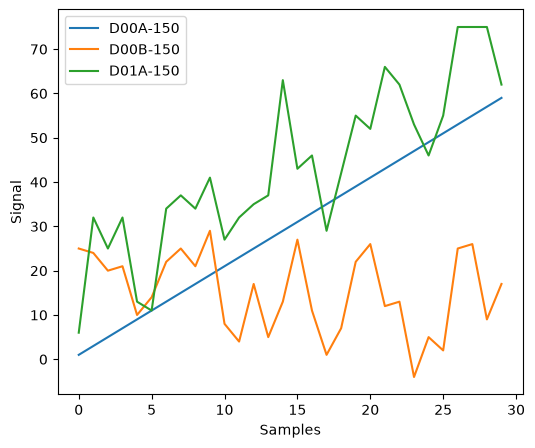

In [204]:
seasick = SeaSick(sine_freq = 1, sine_amp = 10, noise_amp = 25)

slow_increase.apply(data, detectors = ["D01A-150"])
seasick.apply(data, detectors = ["D01A-150"])

plt.figure(figsize=(6,5))
plt.plot(ob.detdata['signal']['D00A-150'], label = 'D00A-150')
plt.plot(ob.detdata['signal']['D00B-150'], label = 'D00B-150')
plt.plot(ob.detdata['signal']['D01A-150'], label = 'D01A-150')
plt.xlabel("Samples")
plt.ylabel("Signal")
plt.legend()
plt.show()

<span style="color: red;">Excercise:</span> 
Create your own operator that [flips](https://en.wikipedia.org/wiki/Verlan) the timestream swapping the first half of the timestream with the second half. A template has been provided.


In [ ]:
class Verlan(Operator):
    """
    Description: Flips the timestream so the first half is second and vice versa.
    """

    # Put any arguments here

    @function_timer
    def _exec(self, data, detectors=None, use_accel=None, **kwargs):

        return
    
    def _finalize(self, data, **kwargs):
        return

# A TOAST-style Operator

In [ ]:
PointingDetector = toast.ops.PointingDetectorSimple(
    boresight=defaults.boresight_azel,
    quats="quats_azel"
)

In [ ]:
@trait_docs
class OperatorTemplate(Operator):
    """
    This is the framework for an operator.

    # Traits
    - Class traits are the arguments that can be passed to the operator when it is instantiated. They are also used to validate the input arguments. The variable names must match the names of the arguments when the operator is called/instantiated. Each trait has a type defined by the trait class. The different trait class options are largely taken from the traitlets package. To use these traits, the traits must be imported from the toast/traits.py file. Common trait types include Bool, Int, Quantity, Unicode, UseEnum. Each trait definition includes a default value and a help string. The help string is used to generate documentation for the operator.

    - API Trait - Every TOAST Operator has an API version number. This is an integer that is used to indicate the version of the operator.
    - Common traits - while every operator is unique, there are some common traits that are used in many operators. These include: 
        - det_mask (Bit mask value for per-detector flagging), 
        - shared_flags (Observation shared key for telescope flags to use), 
        - shared_flag_mask (Bit mask value for optional flagging), 
        - boresight (Observation shared key for boresight), 
        - hwp_angle (Observation shared key for HWP angle), 
        - quats (Observation detdata key for output quaternions), 
        - coord_in (The input boresight coordinate system ('C', 'E', 'G')), 
        - coord_out (The output coordinate system ('C', 'E', 'G')).

    # Validators
    Validators are functions that are used to validate the input arguments. They are defined using the @traitlets.validate decorator and are called when the operator is instantiated. The function name must be _check_<trait_name> where <trait_name> is the name of the trait being validated. The function must take a single argument, proposal, which is a dictionary containing the value of the trait being validated. The function must return the value of the trait if it is valid, or raise a traitlets.TraitError if it is not valid.

    # Execution
    The _exec function is the main execution function of the operator. It is called when the operator is applied to the data. It generally takes the data object, a list of detectors, a boolean flag indicating whether to use an accelerator, and any number of keyword arguments. The function should perform the main work of the operator and return any results. Most of the interesting functionality of the operator will be implemented within a loop over the observations (and sometimes detectors) stored within the _exec function. The _exec function typically does not return anything as it primarily assigns values to various object attributes.

    # Finalize
    TOAST operators need a _finalize function that is called after the _exec function. This function is used to perform any finalization steps that are needed after the main execution of the operator. It generally takes the data object and any number of keyword arguments. Typically, this function is empty and relies on the _finalize function in the parent Operator clas.

    # Requirements
    The _requires function is used to specify the requirements of the operator. It returns a dictionary of Observation keys directly used by this Operator. Including optional keys that will be created by the operator if they do not exist. Metadata keys are those contained in the primary observation dictionary.  Detdata, shared, and intervals keys are those contained in the "detdata", "shared", and "intervals" observation attributes.

    # Provides
    Returns the keys in the Observation dictionary that will be created or modified.
    """
    API = Int(0, help="Internal interface version for this operator")

    test_trait = Int(
        0,
        help="This is a test trait for the operator",
    )

    det_mask = Int(
        defaults.det_mask_invalid,
        help="Bit mask value for per-detector flagging",
    )

    boresight = Unicode(
        defaults.boresight_radec, help="Observation shared key for boresight"
    )

    quats = Unicode(
        defaults.quats,
        allow_none=True,
        help="Observation detdata key for output quaternions",
    )

    # This is an example of a trait validator.
    @traitlets.validate("test_trait")
    def _check_test_trait(self, proposal):
        check = proposal["value"]
        if check < 0:
            raise traitlets.TraitError("Test trait should be a positive integer")
        return check

    # This is the operator constructor. It is called when the operator is instantiated. It takes any number of keyword arguments and passes them to the parent class constructor. The parent class constructor will validate the input arguments and set the class traits.
    def __init__(self, **kwargs):
        super().__init__(**kwargs)


    @function_timer
    def _exec(self, data, detectors=None, use_accel=None, **kwargs):
        log = Logger.get()

        # Kernel selection
        implementation, use_accel = self.select_kernels(use_accel=use_accel)

        for ob in data.obs:
            # Get the detectors we are using for this observation
            dets = ob.select_local_detectors(detectors, flagmask=self.det_mask)

        return

    def _finalize(self, data, **kwargs):
        return

    def _requires(self):
        req = {
            "meta": list(),
            "shared": [self.boresight],
            "detdata": [self.quats],
            "intervals": list(),
        }
        if self.shared_flags is not None:
            req["shared"].append(self.shared_flags)
        if self.view is not None:
            req["intervals"].append(self.view)
        return req

    def _provides(self):
        prov = {
            "meta": list(),
            "shared": list(),
            "detdata": [self.quats],
        }
        return prov

    def _supports_accel(self):
        return True
